# Task 2 & 3 — Thống kê mô tả, Trực quan hóa & Khám phá dữ liệu (EDA)

**Input:** `shots_worldcup_2018_2022_raw.csv` — output của Task 1 (3200 shot từ 128 trận World Cup 2018 + 2022).

**Cấu trúc notebook:**
- **Task 2** — Trực quan hóa cơ bản (histogram, bar chart) + thống kê mô tả (dispersion, quartile, z-score, box plot, skewness, kurtosis).
- **Task 3** — EDA chuyên sâu (heatmap không gian, heatmap tương quan, xu hướng theo thời gian với Moving Average, Control Chart, Correlation vs Regression, Correlation vs Causation, Random Sampling & Central Limit Theorem) — chốt lại bằng bảng quyết định thiết kế cho Task 4 (Preprocessing).

Ghi chú: `keeper_x`/`keeper_y` bị thiếu ở một số shot (thủ môn không xuất hiện trong `freeze_frame`) — đã biết từ Task 1, không lặp lại kiểm tra ở đây. `outcome` và `statsbomb_xg` chỉ được dùng để **diễn giải/validate**, không đưa vào bất kỳ bước chọn feature nào.


## 0 — Setup

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

CSV_PATH = "/kaggle/input/datasets/tunlcvcng/wc-2018-2022/shots_worldcup_2018_2022_raw.csv"  # đổi lại nếu bạn chạy ở nơi khác
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df.shape


(3200, 30)

---
# TASK 2 — Trực quan hóa cơ bản & Thống kê mô tả

## 2.1 — Tổng quan dữ liệu

In [2]:
print("Shape:", df.shape)
df.head(3)


Shape: (3200, 30)


,event_id,match_id,season_id,team_id,team_name,player_id,player_name,period,minute,second,...,aerial_won,open_goal,n_teammates_in_frame,n_opponents_in_frame,keeper_x,keeper_y,end_location_x,end_location_y,outcome,statsbomb_xg
0,9d2b23a7-0fde-45f1-8b6e-58fc9da4aab5,8650,3,782,Belgium,3089,Kevin De Bruyne,1,1,34,...,False,False,4,8,118.0,41.0,120.0,34.8,Off T,0.020461
1,ff6fee87-0f6b-461e-a5fd-e5032aa19564,8650,3,781,Brazil,3295,Thiago Emiliano da Silva,1,7,12,...,False,False,4,8,118.0,38.0,120.0,35.8,Post,0.274021
2,ebeaf37c-a1be-46a4-b3bb-ae4779458734,8650,3,782,Belgium,3621,Eden Hazard,1,7,32,...,False,False,2,8,119.0,39.0,109.0,31.0,Blocked,0.065900


keeper_x    125
keeper_y    125
dtype: int64


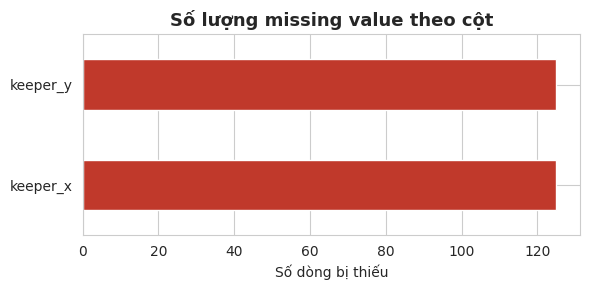

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Số lượng missing value theo cột")
ax.set_xlabel("Số dòng bị thiếu")
plt.tight_layout()
plt.show()


## 2.2 — Bar chart: phân bố các biến phân loại

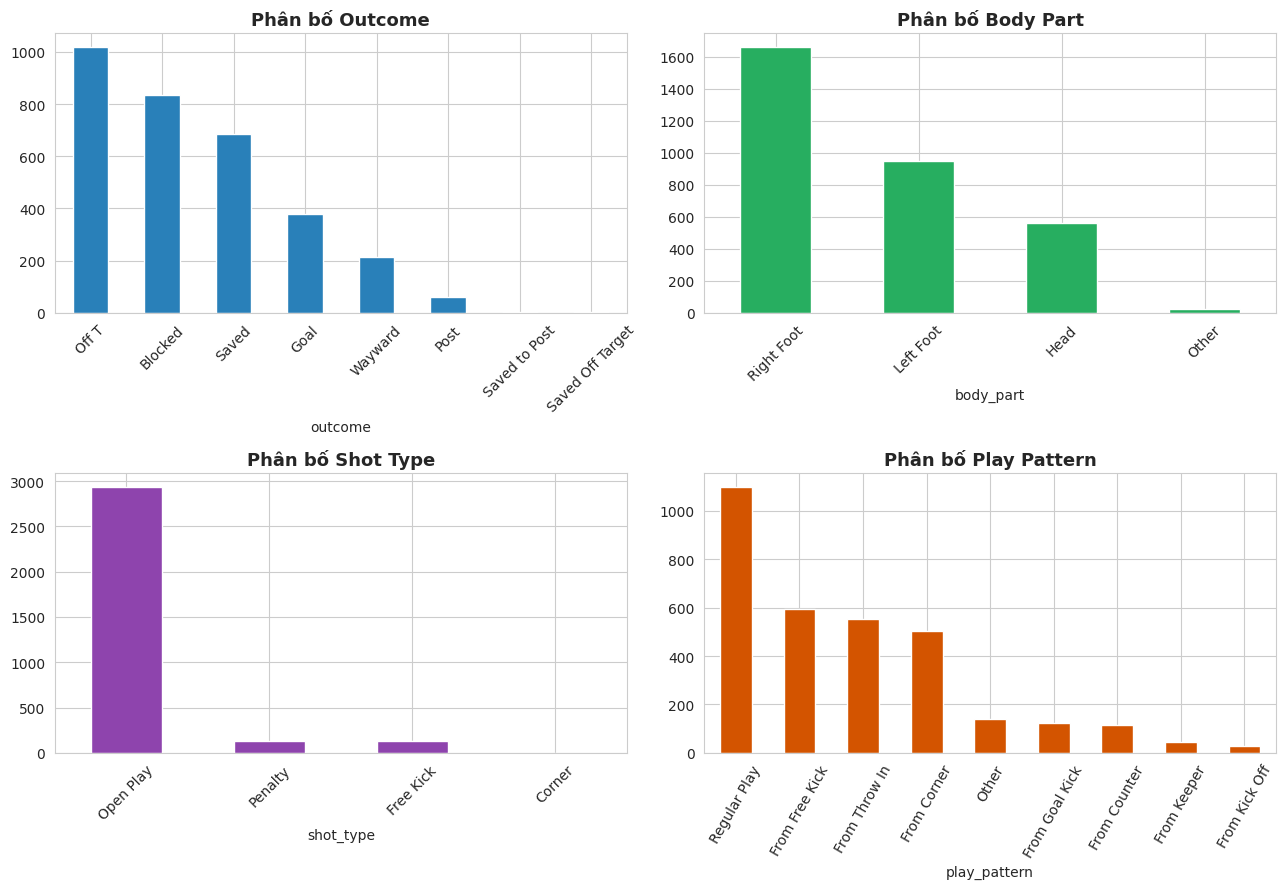

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df["outcome"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#2980b9")
axes[0, 0].set_title("Phân bố Outcome")
axes[0, 0].tick_params(axis="x", rotation=45)

df["body_part"].value_counts().plot(kind="bar", ax=axes[0, 1], color="#27ae60")
axes[0, 1].set_title("Phân bố Body Part")
axes[0, 1].tick_params(axis="x", rotation=45)

df["shot_type"].value_counts().plot(kind="bar", ax=axes[1, 0], color="#8e44ad")
axes[1, 0].set_title("Phân bố Shot Type")
axes[1, 0].tick_params(axis="x", rotation=45)

df["play_pattern"].value_counts().plot(kind="bar", ax=axes[1, 1], color="#d35400")
axes[1, 1].set_title("Phân bố Play Pattern")
axes[1, 1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


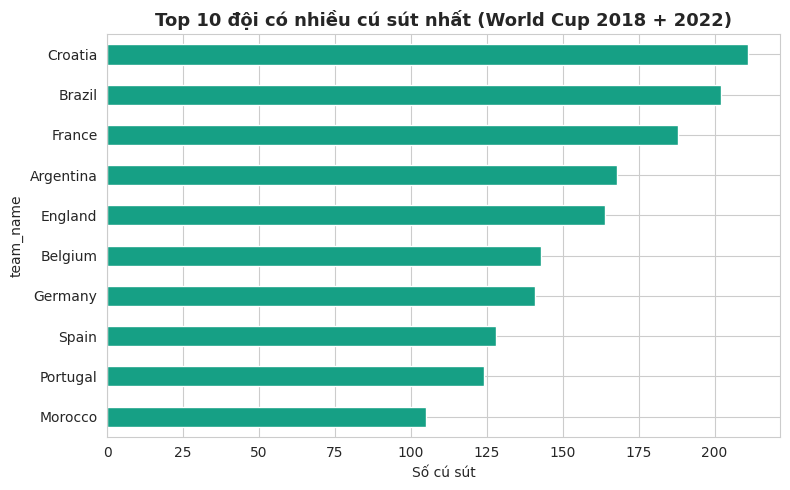

In [5]:
top_teams = df["team_name"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_teams.sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Top 10 đội có nhiều cú sút nhất (World Cup 2018 + 2022)")
ax.set_xlabel("Số cú sút")
plt.tight_layout()
plt.show()


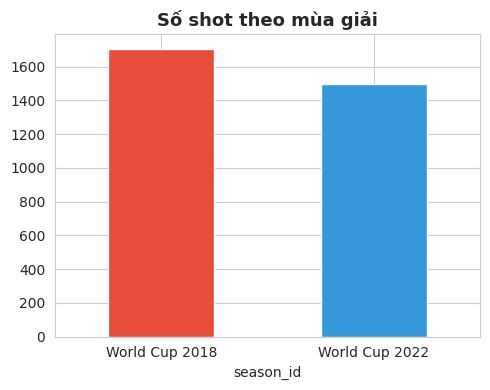

season_id
World Cup 2018    1706
World Cup 2022    1494
Name: count, dtype: int64


In [6]:
season_labels = {3: "World Cup 2018", 106: "World Cup 2022"}
season_counts = df["season_id"].map(season_labels).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
season_counts.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"])
ax.set_title("Số shot theo mùa giải")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(season_counts)


## 2.3 — Histogram: phân bố các biến định lượng

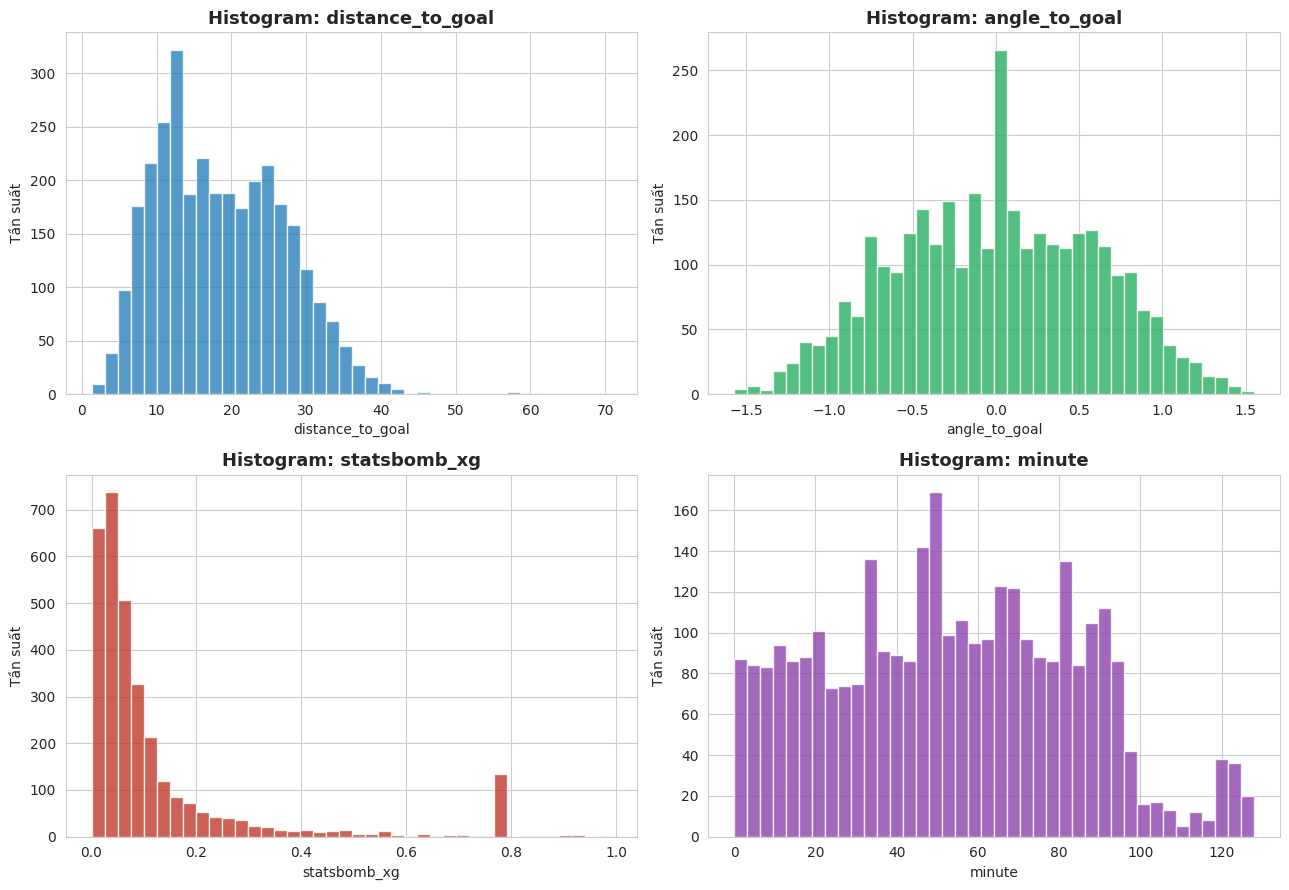

In [7]:
numeric_cols = ["distance_to_goal", "angle_to_goal", "statsbomb_xg", "minute"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
colors = ["#2980b9", "#27ae60", "#c0392b", "#8e44ad"]

for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.8)
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Tần suất")

plt.tight_layout()
plt.show()


**Quan sát nhanh:** `statsbomb_xg` lệch phải rất mạnh (đa số cú sút có xG thấp, một số ít cơ hội rõ ràng/penalty đẩy đuôi phân phối dài về bên phải) — phần Skewness/Kurtosis ở mục 2.9 sẽ định lượng chính xác điều này. `distance_to_goal` cũng lệch phải nhẹ (đa số sút gần khung thành hơn). `angle_to_goal` khá đối xứng quanh 0 (hợp lý vì góc âm/dương chỉ là hướng trái/phải, không có lý do lệch hẳn về một phía). `minute` cho thấy phân bố sút tương đối đều theo thời gian trận, có thể nhích lên ở cuối hiệp — sẽ xem kỹ hơn ở mục Line Chart (3.4).

## 2.4 — Bảng thống kê mô tả tổng hợp

In [8]:
desc = df[numeric_cols].describe().T
desc


,count,mean,std,min,25%,50%,75%,max
distance_to_goal,3200.0,18.625261,8.488190,1.315295,11.900420,17.768650,25.000000,70.830784
angle_to_goal,3200.0,-0.003854,0.596125,-1.570796,-0.457393,0.000000,0.463648,1.550443
statsbomb_xg,3200.0,0.122290,0.180206,0.000180,0.028790,0.059033,0.116540,0.991189
minute,3200.0,53.650937,30.289997,0.000000,30.000000,53.000000,77.000000,128.000000


## 2.5 — Đo lường độ phân tán (Dispersion): Std, Variance, Range, IQR

- **Standard Deviation / Variance**: đo mức độ dữ liệu dao động quanh giá trị trung bình.
- **Range**: khoảng cách giữa giá trị lớn nhất và nhỏ nhất — nhạy với outlier.
- **IQR (Interquartile Range) = Q3 − Q1**: đo độ phân tán của "phần giữa" dữ liệu, ít bị outlier chi phối hơn Range.

In [9]:
dispersion_rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    dispersion_rows.append({
        "feature": col,
        "std": s.std(),
        "variance": s.var(),
        "range": s.max() - s.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
    })

dispersion_df = pd.DataFrame(dispersion_rows).set_index("feature")
dispersion_df


,std,variance,range,Q1,Q3,IQR
feature,,,,,,
distance_to_goal,8.488190,72.049375,69.515490,11.900420,25.000000,13.099580
angle_to_goal,0.596125,0.355365,3.121239,-0.457393,0.463648,0.921040
statsbomb_xg,0.180206,0.032474,0.991009,0.028790,0.116540,0.087751
minute,30.289997,917.483932,128.000000,30.000000,77.000000,47.000000


**Nhận xét dựa trên số liệu thật:** `distance_to_goal` có IQR ≈ 13 mét quanh trung vị — đa số cú sút nằm trong khoảng khá hẹp gần khung thành, đúng như kỳ vọng bóng đá thực tế (phần lớn cơ hội đến từ trong/ngay ngoài vòng cấm). `statsbomb_xg` có IQR nhỏ hơn nhiều so với Range (Range ≈ 0.99 nhưng IQR chỉ ≈ 0.09) — chênh lệch lớn giữa 2 chỉ số này là dấu hiệu rõ của phân phối lệch mạnh, sẽ dùng Range vs IQR để minh họa vì sao Range dễ bị outlier (như quả penalty/open-goal) kéo méo hơn IQR.

## 2.6 — Box-and-Whisker Plot

/tmp/ipykernel_58/3350026619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="outcome", y="distance_to_goal", ax=axes[0], palette="Set2")
/tmp/ipykernel_58/3350026619.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="body_part", y="statsbomb_xg", ax=axes[1], palette="Set3")


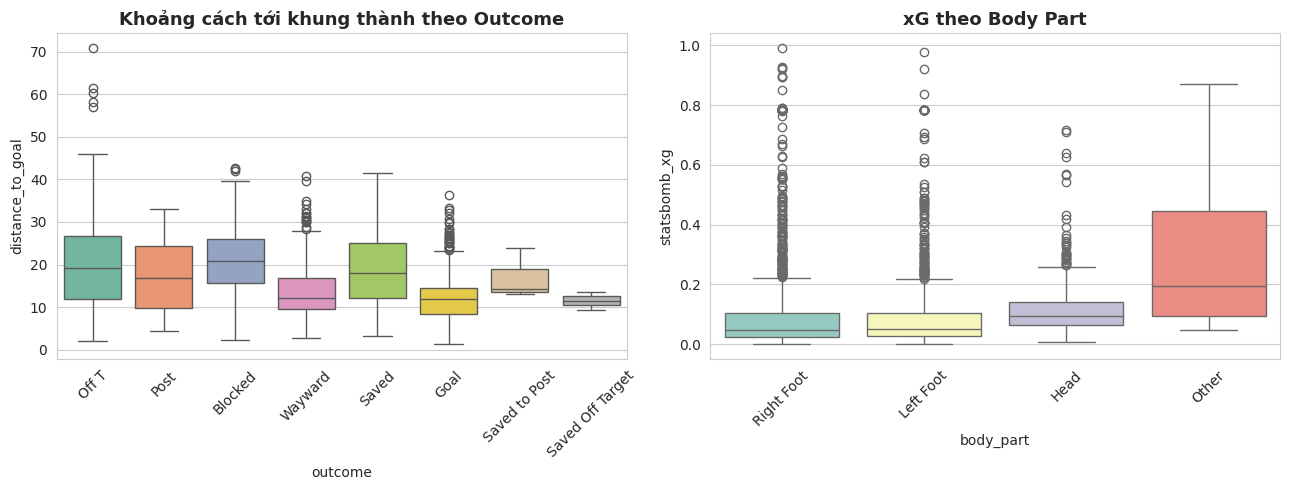

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="outcome", y="distance_to_goal", ax=axes[0], palette="Set2")
axes[0].set_title("Khoảng cách tới khung thành theo Outcome")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="body_part", y="statsbomb_xg", ax=axes[1], palette="Set3")
axes[1].set_title("xG theo Body Part")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Box plot cho thấy trực quan cùng thông tin với bảng IQR ở mục 2.5 (đường giữa hộp = median, 2 cạnh hộp = Q1/Q3, râu = 1.5×IQR, chấm ngoài râu = outlier theo quy ước box plot) — nhóm **Goal** có `distance_to_goal` thấp hơn và tập trung hơn rõ rệt so với các outcome khác, khớp với trực giác: sút gần khung thành có tỷ lệ ghi bàn cao hơn.

## 2.7 — Đo lường vị trí: Quartile, Percentile & Z-score

Ngoài Q1/Q3 đã tính, xem thêm các percentile khác (ví dụ 95th, 99th) để biết ngưỡng "cơ hội cực tốt" nằm ở đâu. Sau đó dùng **Z-score** để đánh dấu các shot bất thường về xG so với phần còn lại.

In [11]:
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_table = df["statsbomb_xg"].quantile(percentiles)
pct_table


0.05    0.008584
0.10    0.012903
0.25    0.028790
0.50    0.059033
0.75    0.116540
0.90    0.288108
0.95    0.626426
0.99    0.783500
Name: statsbomb_xg, dtype: float64

In [12]:
df["xg_zscore"] = stats.zscore(df["statsbomb_xg"])

n_outliers = (df["xg_zscore"].abs() > 3).sum()
pct_outliers = n_outliers / len(df) * 100
print(f"Số shot có |z-score| > 3: {n_outliers} ({pct_outliers:.1f}% tổng số shot)")

df.sort_values("xg_zscore", ascending=False)[
    ["player_name", "team_name", "distance_to_goal", "statsbomb_xg", "outcome", "xg_zscore"]
].head(5)


Số shot có |z-score| > 3: 157 (4.9% tổng số shot)


,player_name,team_name,distance_to_goal,statsbomb_xg,outcome,xg_zscore
103,M'Baye Babacar Niang,Senegal,7.000000,0.991189,Goal,4.822450
1232,Eden Hazard,Belgium,11.180340,0.979034,Goal,4.754991
255,Kylian Mbappé Lottin,France,1.414214,0.929318,Goal,4.479061
1067,Neymar da Silva Santos Junior,Brazil,3.162278,0.925740,Goal,4.459207
1515,Heung-Min Son,South Korea,8.944272,0.922626,Goal,4.441922


**Điểm đáng chú ý:** với dữ liệu chuẩn (normal) thì quy tắc |z| > 3 chỉ nên gắn cờ khoảng 0.3% dữ liệu, nhưng ở đây con số thực tế cao hơn hẳn (~5%). Đây **không phải lỗi tính toán**, mà vì `statsbomb_xg` lệch phải rất mạnh (đã thấy ở histogram và skewness) — Z-score dựa trên giả định phân phối gần chuẩn, nên áp dụng máy móc ngưỡng "3 sigma" lên một biến lệch nặng sẽ gắn cờ nhầm nhiều điểm hợp lệ (các cơ hội ngon ăn) thành "outlier". Đây là lý do quan trọng để không dùng Z-score mù quáng làm bước loại outlier ở Task 4 sau này mà không xem qua phân phối trước.

## 2.8 — Skewness & Kurtosis

- **Skewness**: đo độ bất đối xứng. Dương = đuôi dài bên phải, Âm = đuôi dài bên trái, ≈0 = đối xứng.
- **Kurtosis** (excess, so với phân phối chuẩn = 0): dương = đuôi dày hơn/nhọn hơn phân phối chuẩn (leptokurtic), âm = đuôi mỏng hơn/bẹt hơn (platykurtic).

In [13]:
skew_kurt_rows = []
for col in ["distance_to_goal", "angle_to_goal", "statsbomb_xg"]:
    s = df[col].dropna()
    skew_kurt_rows.append({
        "feature": col,
        "skewness": stats.skew(s),
        "kurtosis_excess": stats.kurtosis(s),
    })

skew_kurt_df = pd.DataFrame(skew_kurt_rows).set_index("feature")
skew_kurt_df


,skewness,kurtosis_excess
feature,,
distance_to_goal,0.517657,0.233568
angle_to_goal,-0.008140,-0.644936
statsbomb_xg,2.742115,7.072596


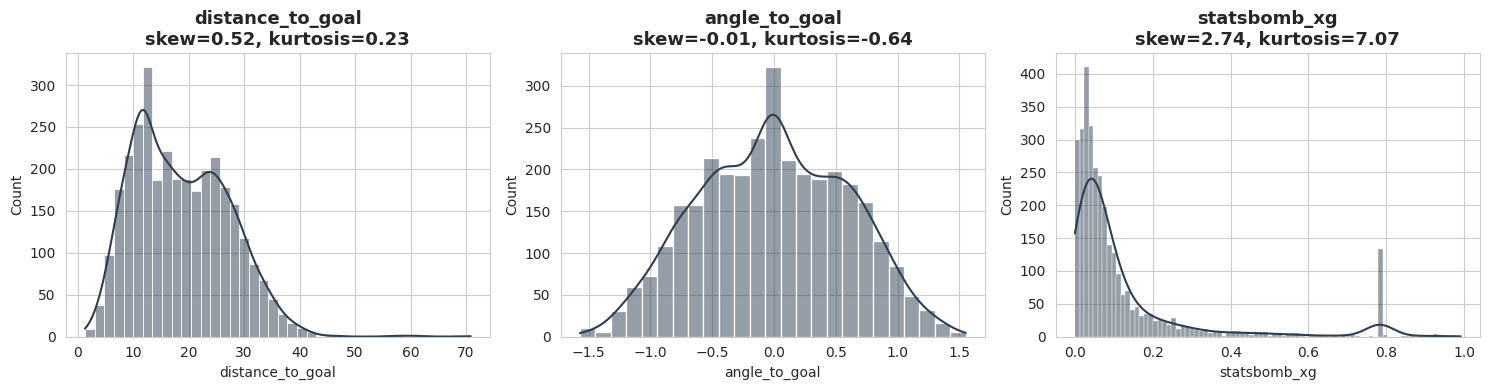

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["distance_to_goal", "angle_to_goal", "statsbomb_xg"]):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#2c3e50")
    sk = skew_kurt_df.loc[col, "skewness"]
    ku = skew_kurt_df.loc[col, "kurtosis_excess"]
    ax.set_title(f"{col}\nskew={sk:.2f}, kurtosis={ku:.2f}")

plt.tight_layout()
plt.show()


**Kết luận từ số liệu thật:** `statsbomb_xg` có skewness ≈ 2.7 (lệch phải rất mạnh) và kurtosis ≈ 7.1 (đuôi rất dày, nhiều giá trị cực đoan hơn hẳn phân phối chuẩn) — đây là biến "khó chịu" nhất trong 3 biến. `distance_to_goal` lệch phải nhẹ (skew ≈ 0.5), gần với phân phối chuẩn hơn (kurtosis ≈ 0.2). `angle_to_goal` gần như đối xứng hoàn hảo (skew ≈ 0) và hơi bẹt hơn chuẩn (kurtosis ≈ −0.6). Kết luận này củng cố quyết định ở Task 4: **cần chuẩn hóa/cân nhắc biến đổi (log, sqrt...) cho `statsbomb_xg` nếu dùng trong bất kỳ mô hình giả định phân phối chuẩn nào** — dù bản thân `statsbomb_xg` không được đưa vào K-Means (nó thuộc nhóm field giấu để validate), thông tin này vẫn hữu ích để hiểu dữ liệu.

---
# TASK 3 — Khám phá dữ liệu chuyên sâu (EDA)

## 3.1 — Kiểm tra tính hợp lệ tọa độ

In [15]:
invalid_x = ~df["location_x"].between(0, 120)
invalid_y = ~df["location_y"].between(0, 80)
print("Số điểm x ngoài [0,120]:", invalid_x.sum())
print("Số điểm y ngoài [0,80]:", invalid_y.sum())


Số điểm x ngoài [0,120]: 0
Số điểm y ngoài [0,80]: 0


## 3.2 — Heat map không gian: mật độ vị trí sút trên sân

Vẽ sơ đồ sân đơn giản (hệ tọa độ StatsBomb 120×80) làm nền, sau đó overlay heatmap mật độ 2D của toàn bộ vị trí sút.

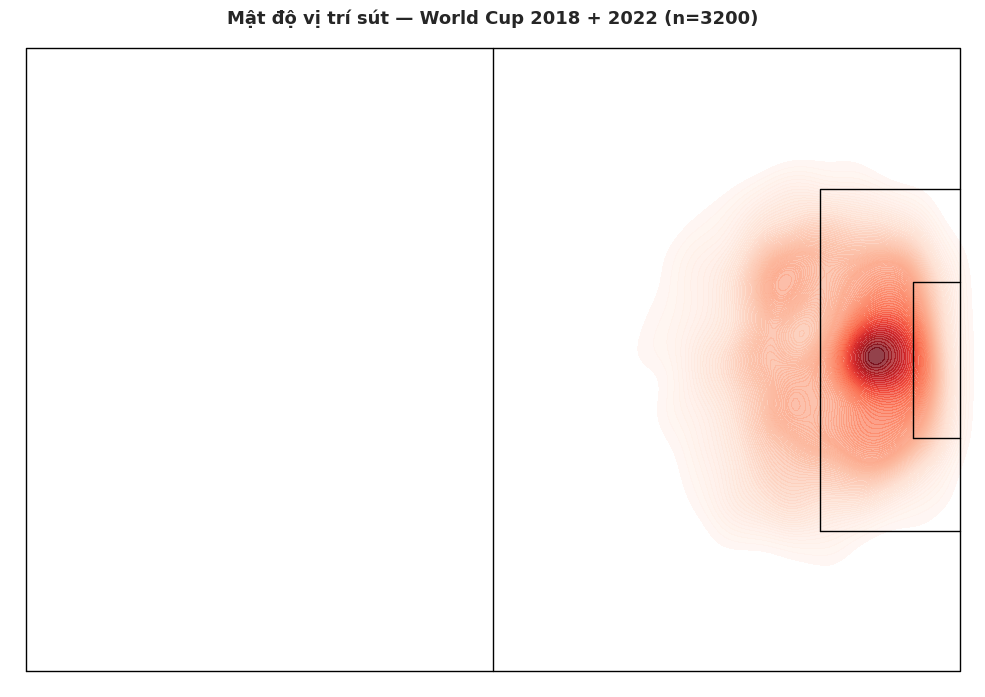

In [16]:
def draw_pitch(ax):
    # Đường biên sân
    ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color="black", linewidth=1)
    # Đường giữa sân
    ax.plot([60, 60], [0, 80], color="black", linewidth=1)
    # Vòng cấm bên phải (nơi tập trung shot, StatsBomb luôn chuẩn hóa hướng tấn công về x=120)
    ax.plot([102, 102, 120], [18, 62, 62], color="black", linewidth=1)
    ax.plot([102, 120], [18, 18], color="black", linewidth=1)
    # Khu vực 6 yard
    ax.plot([114, 114, 120], [30, 50, 50], color="black", linewidth=1)
    ax.plot([114, 120], [30, 30], color="black", linewidth=1)
    ax.set_xlim(-2, 122)
    ax.set_ylim(-2, 82)
    ax.set_aspect("equal")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)
sns.kdeplot(
    data=df, x="location_x", y="location_y",
    fill=True, cmap="Reds", alpha=0.75, levels=100, thresh=0.02, ax=ax,
)
ax.set_title("Mật độ vị trí sút — World Cup 2018 + 2022 (n=3200)")
plt.tight_layout()
plt.show()


Kèm theo scatter (không làm mượt) để đối chiếu, tránh KDE làm mất chi tiết các cụm nhỏ:

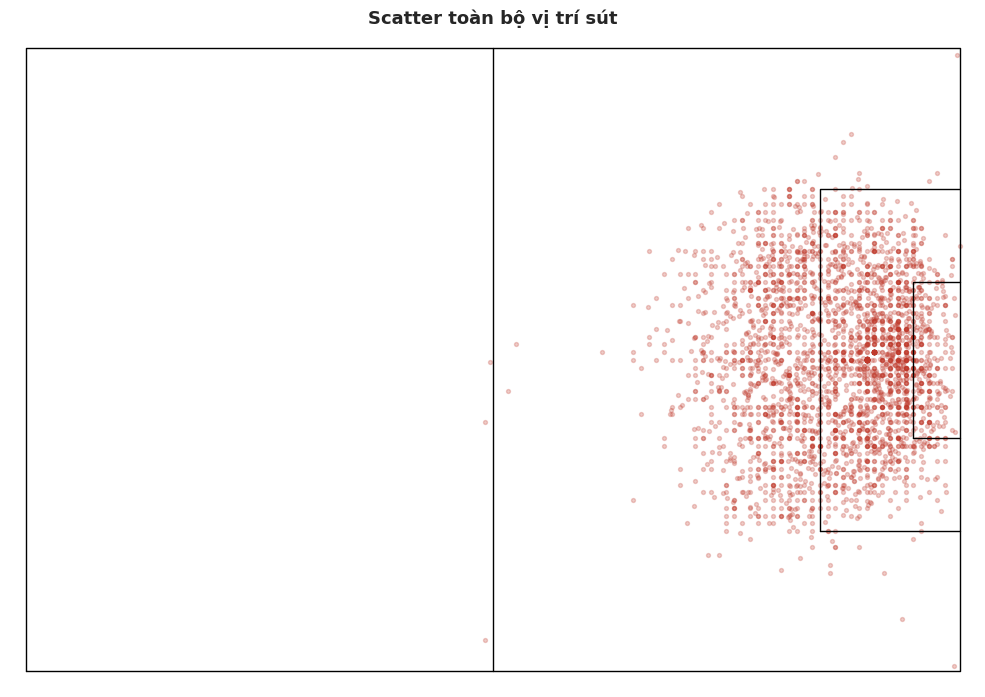

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)
ax.scatter(df["location_x"], df["location_y"], s=8, alpha=0.25, color="#c0392b")
ax.set_title("Scatter toàn bộ vị trí sút")
plt.tight_layout()
plt.show()


## 3.3 — Heat map tương quan (Correlation Heatmap)

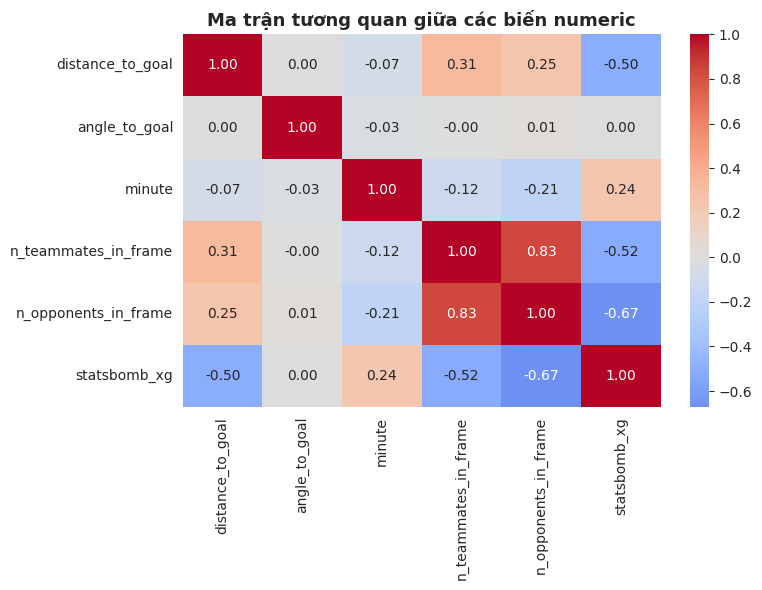

In [18]:
corr_cols = [
    "distance_to_goal", "angle_to_goal", "minute",
    "n_teammates_in_frame", "n_opponents_in_frame", "statsbomb_xg",
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Ma trận tương quan giữa các biến numeric")
plt.tight_layout()
plt.show()


**Đọc kết quả:** `distance_to_goal` tương quan âm vừa phải với `statsbomb_xg` (r ≈ −0.50, đúng kỳ vọng: xa hơn → xG thấp hơn). `n_opponents_in_frame` cũng có tương quan âm với `statsbomb_xg` — nhiều hậu vệ xuất hiện trong khung hình thường đi kèm cơ hội khó hơn. Không có cặp feature nào dự kiến đưa vào K-Means (`distance_to_goal`, `angle_to_goal`, `n_opponents_in_frame`...) tương quan quá cao với nhau (>0.8) — nghĩa là chưa cần loại bớt feature nào vì trùng lặp thông tin, khác với lo ngại ban đầu về việc `distance` và tọa độ `x` có thể trùng lặp (ở đây ta không đưa cả 2 vào X nên không phát sinh vấn đề).

## 3.4 — Line Chart & Moving Average (SMA, EMA): xu hướng chất lượng cơ hội theo thời gian trận đấu

Gộp toàn bộ shot theo từng phút (0–90+), tính xG trung bình mỗi phút. Chuỗi thô sẽ khá nhiễu (mỗi phút chỉ có vài chục shot) nên áp thêm **SMA (Simple Moving Average)** và **EMA (Exponential Moving Average)** để làm mượt và so sánh.

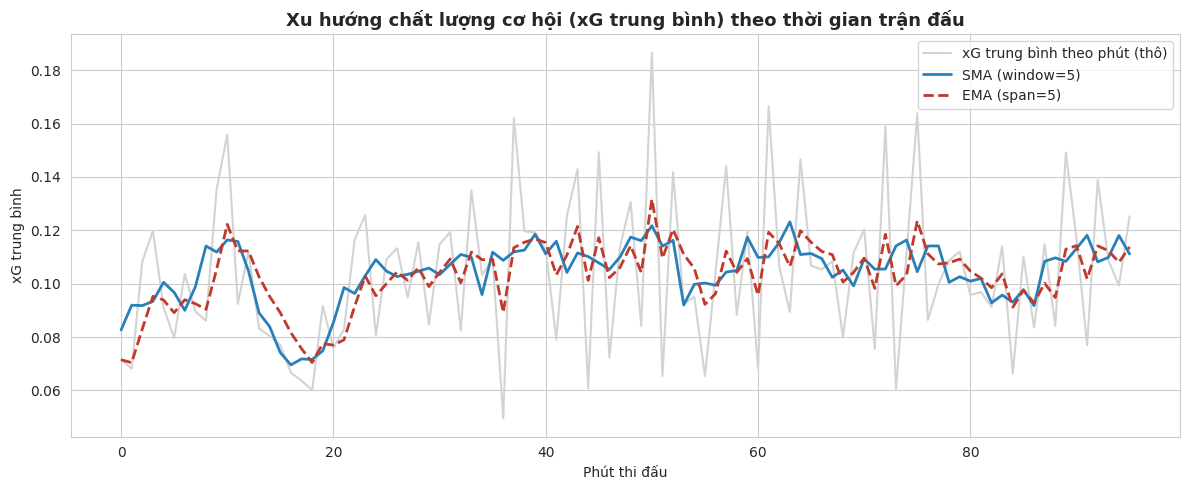

In [19]:
by_minute = df.groupby("minute")["statsbomb_xg"].agg(["mean", "count"]).rename(columns={"mean": "avg_xg"})
by_minute = by_minute[by_minute.index <= 95]  # bỏ vài phút bù giờ cực hiếm để chuỗi gọn hơn

WINDOW = 5  # window size cho SMA — đánh đổi: window nhỏ bám sát dữ liệu hơn nhưng nhiễu hơn, window lớn mượt hơn nhưng trễ (lag) hơn
by_minute["SMA"] = by_minute["avg_xg"].rolling(window=WINDOW, min_periods=1, center=True).mean()
by_minute["EMA"] = by_minute["avg_xg"].ewm(span=WINDOW, adjust=False).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(by_minute.index, by_minute["avg_xg"], color="lightgray", label="xG trung bình theo phút (thô)")
ax.plot(by_minute.index, by_minute["SMA"], color="#2980b9", linewidth=2, label=f"SMA (window={WINDOW})")
ax.plot(by_minute.index, by_minute["EMA"], color="#c0392b", linewidth=2, linestyle="--", label=f"EMA (span={WINDOW})")
ax.set_xlabel("Phút thi đấu")
ax.set_ylabel("xG trung bình")
ax.set_title("Xu hướng chất lượng cơ hội (xG trung bình) theo thời gian trận đấu")
ax.legend()
plt.tight_layout()
plt.show()


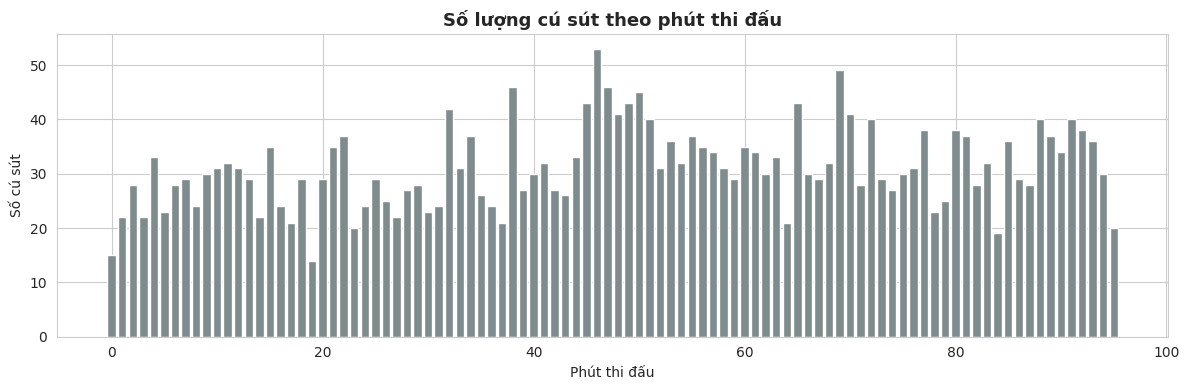

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_minute.index, by_minute["count"], color="#7f8c8d")
ax.set_xlabel("Phút thi đấu")
ax.set_ylabel("Số cú sút")
ax.set_title("Số lượng cú sút theo phút thi đấu")
plt.tight_layout()
plt.show()


**Nhận xét:** SMA và EMA cho hình dạng xu hướng khá giống nhau, khác biệt chủ yếu ở độ trễ — EMA phản ứng nhanh hơn với thay đổi gần nhất vì trọng số giảm dần theo cấp số nhân về quá khứ, còn SMA coi mọi điểm trong window quan trọng như nhau nên mượt hơn nhưng trễ hơn. Biểu đồ số lượng cú sút cho thấy rõ **số lượng shot tăng mạnh về cuối mỗi hiệp** (gần phút 45 và 90) — hợp lý vì các đội thường dồn lên tấn công khi thời gian sắp hết.

## 3.5 — Control Chart: phát hiện trận đấu có chất lượng cơ hội bất thường

Coi mỗi trận đấu là 1 "process output", tính xG trung bình mỗi trận, rồi dựng control chart với đường tâm (mean) và giới hạn kiểm soát UCL/LCL = mean ± 3×std trên toàn bộ 128 trận.

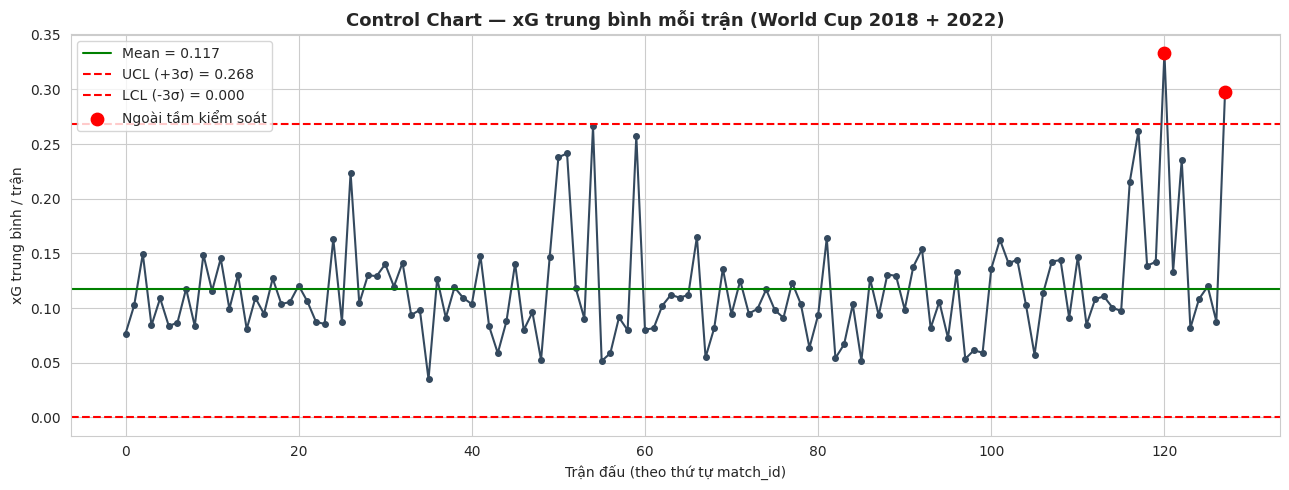

Số trận ngoài tầm kiểm soát: 2


,match_id,statsbomb_xg,season_id
120,3869321,0.333669,106
127,3869685,0.297340,106


In [21]:
match_avg_xg = df.groupby("match_id")["statsbomb_xg"].mean().reset_index()
match_avg_xg = match_avg_xg.merge(
    df[["match_id", "season_id"]].drop_duplicates(), on="match_id"
).sort_values("match_id").reset_index(drop=True)

mu = match_avg_xg["statsbomb_xg"].mean()
sigma = match_avg_xg["statsbomb_xg"].std()
ucl = mu + 3 * sigma
lcl = max(0, mu - 3 * sigma)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(match_avg_xg.index, match_avg_xg["statsbomb_xg"], marker="o", linestyle="-", color="#34495e", markersize=4)
ax.axhline(mu, color="green", linestyle="-", label=f"Mean = {mu:.3f}")
ax.axhline(ucl, color="red", linestyle="--", label=f"UCL (+3σ) = {ucl:.3f}")
ax.axhline(lcl, color="red", linestyle="--", label=f"LCL (-3σ) = {lcl:.3f}")

out_of_control = match_avg_xg[(match_avg_xg["statsbomb_xg"] > ucl) | (match_avg_xg["statsbomb_xg"] < lcl)]
ax.scatter(out_of_control.index, out_of_control["statsbomb_xg"], color="red", s=80, zorder=5, label="Ngoài tầm kiểm soát")

ax.set_xlabel("Trận đấu (theo thứ tự match_id)")
ax.set_ylabel("xG trung bình / trận")
ax.set_title("Control Chart — xG trung bình mỗi trận (World Cup 2018 + 2022)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Số trận ngoài tầm kiểm soát: {len(out_of_control)}")
match_avg_xg.loc[out_of_control.index]


**Kết quả thực tế:** có **2 trận vượt UCL** — cả hai đều thuộc World Cup 2022 và đều có Argentina góp mặt: **Hà Lan 2-2 Argentina** (Tứ kết, thắng luân lưu) và **Argentina 3-3 Pháp** (Chung kết, một trong những trận chung kết được đánh giá kịch tính nhất lịch sử). Đây là minh chứng thú vị: control chart không chỉ là công cụ thống kê trừu tượng mà thực sự "bắt" được đúng những trận đấu có chất lượng cơ hội ăn bàn bất thường cao, khớp với cảm nhận thực tế về các trận đấu đó.

## 3.6 — Correlation vs Regression

Tương quan (correlation) chỉ đo **độ mạnh/chiều** của mối quan hệ tuyến tính, không đưa ra công thức dự đoán. Regression đi xa hơn: ước lượng phương trình đường thẳng tốt nhất để **dự đoán** biến này từ biến kia.

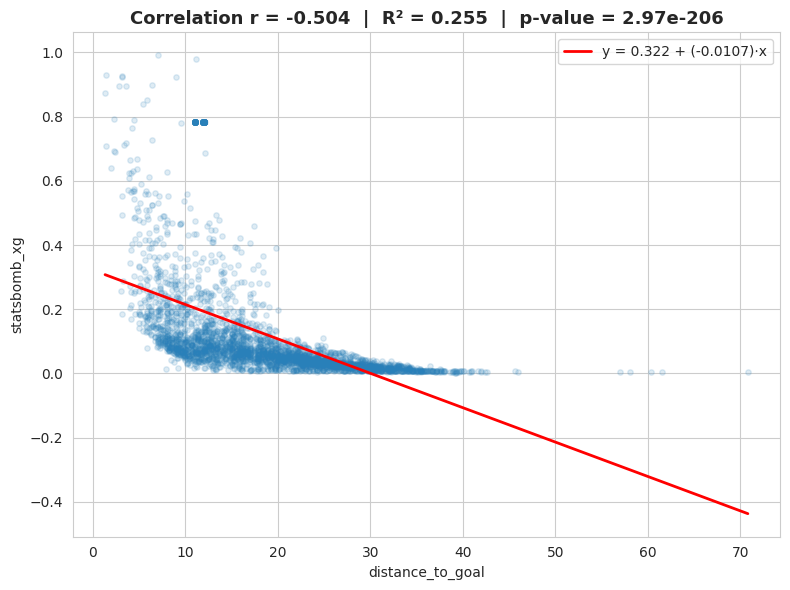

In [22]:
x = df["distance_to_goal"].values
y = df["statsbomb_xg"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.15, color="#2980b9", s=15)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="red", linewidth=2,
        label=f"y = {intercept:.3f} + ({slope:.4f})·x")
ax.set_xlabel("distance_to_goal")
ax.set_ylabel("statsbomb_xg")
ax.set_title(f"Correlation r = {r_value:.3f}  |  R² = {r_value**2:.3f}  |  p-value = {p_value:.2e}")
ax.legend()
plt.tight_layout()
plt.show()


**Diễn giải:** hệ số tương quan r ≈ −0.50 cho biết mối quan hệ nghịch **vừa phải** (không phải cực mạnh) — nghĩa là khoảng cách giải thích được một phần đáng kể sự biến thiên của xG (R² ≈ 0.25, tức khoảng 25%), nhưng còn nhiều yếu tố khác (góc sút, áp lực, vị trí thủ môn...) cũng đóng góp phần còn lại. Phương trình hồi quy `y = intercept + slope·x` là công cụ **dự đoán** cụ thể (cho 1 khoảng cách bất kỳ, ước lượng xG kỳ vọng), trong khi hệ số r chỉ là **con số tóm tắt mức độ liên hệ**, không tự nó dự đoán được giá trị cụ thể — đây là điểm khác biệt cốt lõi giữa 2 khái niệm.

## 3.7 — Correlation vs Causation

`under_pressure` và `statsbomb_xg` có tương quan âm rõ rệt — nhưng liệu **áp lực phòng ngự trực tiếp làm giảm chất lượng cơ hội**, hay đây chỉ là tương quan bị nhiễu bởi một biến thứ ba (confounder), ví dụ: các cú sút bị gây áp lực thường cũng là các cú sút từ xa hơn/góc hẹp hơn?

Cách kiểm tra đơn giản: so sánh `under_pressure` vs `statsbomb_xg` **trong từng nhóm khoảng cách riêng biệt** (kiểm soát biến `distance_to_goal`) — nếu chênh lệch vẫn còn rõ sau khi đã kiểm soát khoảng cách, đó là bằng chứng ủng hộ tác động thật của pressure chứ không chỉ do nhiễu.

In [23]:
raw_compare = df.groupby("under_pressure")["statsbomb_xg"].mean()
print("So sánh thô (chưa kiểm soát gì):")
print(raw_compare)
print()

df["dist_bin"] = pd.cut(df["distance_to_goal"], bins=[0, 10, 20, 30, 100],
                         labels=["0-10m", "10-20m", "20-30m", "30m+"])

controlled_compare = df.groupby(["dist_bin", "under_pressure"], observed=True)["statsbomb_xg"].mean().unstack()
print("So sánh sau khi kiểm soát theo khoảng cách (dist_bin):")
controlled_compare


So sánh thô (chưa kiểm soát gì):
under_pressure
False    0.129975
True     0.086601
Name: statsbomb_xg, dtype: float64

So sánh sau khi kiểm soát theo khoảng cách (dist_bin):


under_pressure,False,True
dist_bin,,
0-10m,0.271598,0.145190
10-20m,0.189210,0.082052
20-30m,0.035781,0.039044
30m+,0.013486,0.012409


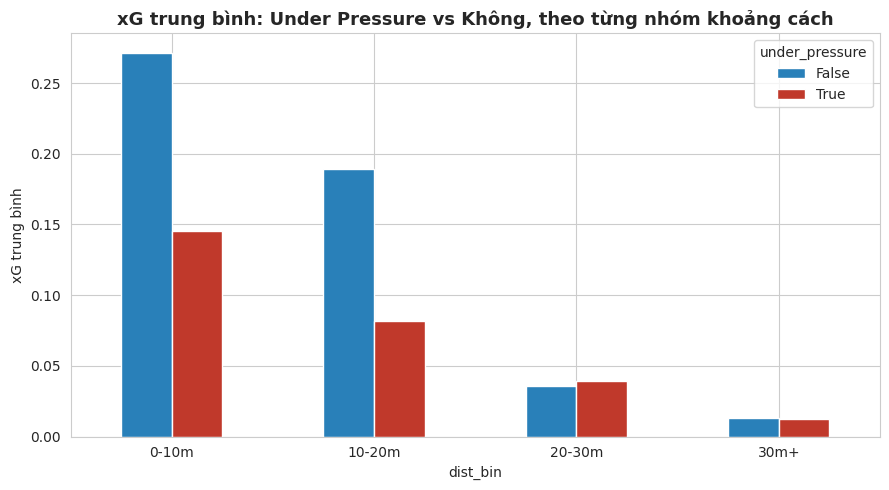

In [24]:
controlled_compare.plot(kind="bar", figsize=(9, 5), color=["#2980b9", "#c0392b"])
plt.title("xG trung bình: Under Pressure vs Không, theo từng nhóm khoảng cách")
plt.ylabel("xG trung bình")
plt.xticks(rotation=0)
plt.legend(title="under_pressure")
plt.tight_layout()
plt.show()


**Kết quả:** ở 3/4 nhóm khoảng cách (đặc biệt 2 nhóm gần khung thành, nơi phần lớn giá trị xG được tạo ra), shot `under_pressure=True` vẫn có xG trung bình thấp hơn rõ rệt so với `under_pressure=False` — chênh lệch **không biến mất** sau khi kiểm soát khoảng cách, cho thấy đây khó có thể chỉ là nhiễu từ khoảng cách. Tuy nhiên ở nhóm 20-30m thì gần như không còn chênh lệch, thậm chí đảo chiều nhẹ. Điều này minh họa đúng tinh thần "correlation ≠ causation": tương quan quan sát được là có thật, kiểm soát 1 biến nhiễu rõ ràng vẫn giữ được phần lớn hiệu ứng, nhưng để khẳng định **quan hệ nhân quả** cần kiểm soát thêm nhiều yếu tố khác (góc sút, kỹ thuật, số hậu vệ chắn...) chứ một phép kiểm tra đơn giản này chưa đủ kết luận chắc chắn.

## 3.8 — Random Sample, Sample Mean & Central Limit Theorem

`statsbomb_xg` (population ở đây) có phân phối lệch phải rất mạnh (skew ≈ 2.7, đã thấy ở mục 2.8) — hoàn toàn không giống phân phối chuẩn. Central Limit Theorem (CLT) khẳng định: dù bản thân population không chuẩn, **phân phối của trung bình mẫu (sample mean)** sẽ tiến gần phân phối chuẩn khi cỡ mẫu `n` đủ lớn. Minh họa bằng cách lấy mẫu ngẫu nhiên lặp lại nhiều lần với các cỡ mẫu khác nhau.

Population: mean=0.1223, std=0.1802, skew=2.7421


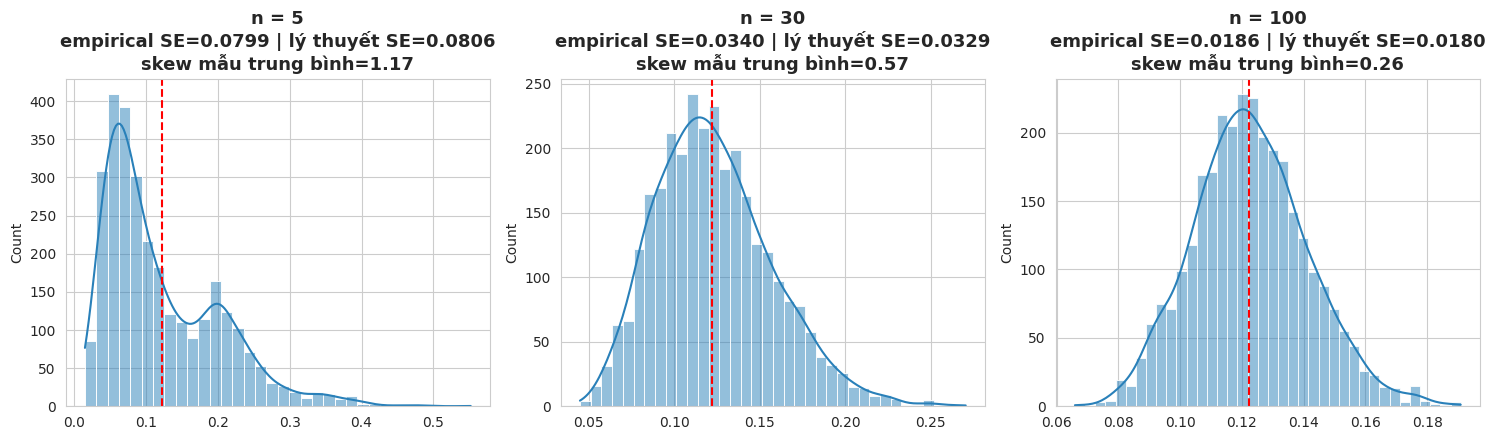

In [25]:
population = df["statsbomb_xg"].dropna().values
pop_mean, pop_std = population.mean(), population.std()
print(f"Population: mean={pop_mean:.4f}, std={pop_std:.4f}, skew={stats.skew(population):.4f}")

rng = np.random.default_rng(42)
N_REPEATS = 3000
sample_sizes = [5, 30, 100]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4.5), sharey=False)

for ax, n in zip(axes, sample_sizes):
    sample_means = np.array([
        rng.choice(population, size=n, replace=True).mean() for _ in range(N_REPEATS)
    ])
    empirical_se = sample_means.std()
    theoretical_se = pop_std / np.sqrt(n)

    sns.histplot(sample_means, kde=True, ax=ax, color="#2980b9")
    ax.set_title(f"n = {n}\nempirical SE={empirical_se:.4f} | lý thuyết SE={theoretical_se:.4f}\nskew mẫu trung bình={stats.skew(sample_means):.2f}")
    ax.axvline(pop_mean, color="red", linestyle="--")

plt.tight_layout()
plt.show()


**Kết quả minh họa CLT rõ ràng trên chính dữ liệu này:**
- Với `n=5`, phân phối trung bình mẫu vẫn còn lệch khá rõ (skew ≈ 1.2) — cỡ mẫu quá nhỏ để "chuẩn hóa" một population lệch mạnh như xG.
- Với `n=30`, độ lệch giảm còn khoảng một nửa (skew ≈ 0.6), hình dạng bắt đầu đối xứng hơn.
- Với `n=100`, phân phối gần như đối xứng (skew ≈ 0.26), rất gần dạng chuông.
- Ở cả 3 trường hợp, **độ lệch chuẩn thực nghiệm của trung bình mẫu (empirical SE) khớp rất sát với công thức lý thuyết SE = σ/√n** — đúng như CLT dự đoán, và SE giảm dần khi n tăng (mẫu càng lớn, trung bình mẫu càng ổn định quanh trung bình thật của population).

Ý nghĩa thực tế cho project: nếu sau này ước lượng "xG trung bình của 1 cụm/1 đội" từ một mẫu nhỏ (ví dụ 1 đội chỉ có 5-10 cú sút trong dữ liệu), ước lượng đó sẽ **kém tin cậy hơn nhiều** so với ước lượng từ mẫu lớn — cần lưu ý khi diễn giải kết quả cụm có cỡ mẫu nhỏ ở Task 6 sau này.

## 3.9 — Tổng hợp: bảng quyết định thiết kế cho Task 4

In [26]:
summary = pd.DataFrame([
    {
        "Phát hiện từ Task 2/3": "distance_to_goal, angle_to_goal, statsbomb_xg có scale rất khác nhau (mét vs radian vs xác suất 0-1)",
        "Quyết định cho Task 4": "Cần thí nghiệm scaled vs unscaled trước khi K-Means (đúng thiết kế ban đầu)",
    },
    {
        "Phát hiện từ Task 2/3": "statsbomb_xg lệch phải rất mạnh (skew≈2.7, kurtosis≈7.1); Z-score>3 gắn cờ ~5% dữ liệu thay vì ~0.3%",
        "Quyết định cho Task 4": "Không dùng Z-score đơn thuần để loại outlier trên biến lệch mạnh; statsbomb_xg vẫn chỉ dùng để validate, không đưa vào X",
    },
    {
        "Phát hiện từ Task 2/3": "Không có cặp feature ứng viên nào tương quan > 0.8 trong corr heatmap",
        "Quyết định cho Task 4": "Chưa cần loại bớt feature vì trùng lặp thông tin",
    },
    {
        "Phát hiện từ Task 2/3": "keeper_x/keeper_y thiếu ở 125/3200 shot (~3.9%)",
        "Quyết định cho Task 4": "Có thể giữ lại (tỷ lệ thiếu nhỏ) — cân nhắc loại dòng thiếu hoặc impute nếu đưa keeper location vào X",
    },
    {
        "Phát hiện từ Task 2/3": "Cỡ mẫu 3200 shot, đủ lớn cho Elbow/Silhouette/Gap Statistic + k-fold CV theo CLT (n=100 đã gần chuẩn)",
        "Quyết định cho Task 4": "Không cần mở rộng thêm dữ liệu trước khi bước vào modeling",
    },
    {
        "Phát hiện từ Task 2/3": "under_pressure có liên hệ với xG thấp hơn, còn giữ sau khi kiểm soát khoảng cách (trừ nhóm 20-30m)",
        "Quyết định cho Task 4": "Giữ under_pressure làm feature cho X (có tín hiệu thật, không chỉ nhiễu từ khoảng cách)",
    },
])

pd.set_option("display.max_colwidth", 100)
summary


,Phát hiện từ Task 2/3,Quyết định cho Task 4
0,"distance_to_goal, angle_to_goal, statsbomb_xg có scale rất khác nhau (mét vs radian vs xác suất ...",Cần thí nghiệm scaled vs unscaled trước khi K-Means (đúng thiết kế ban đầu)
1,"statsbomb_xg lệch phải rất mạnh (skew≈2.7, kurtosis≈7.1); Z-score>3 gắn cờ ~5% dữ liệu thay vì ~...",Không dùng Z-score đơn thuần để loại outlier trên biến lệch mạnh; statsbomb_xg vẫn chỉ dùng để v...
2,Không có cặp feature ứng viên nào tương quan > 0.8 trong corr heatmap,Chưa cần loại bớt feature vì trùng lặp thông tin
3,keeper_x/keeper_y thiếu ở 125/3200 shot (~3.9%),Có thể giữ lại (tỷ lệ thiếu nhỏ) — cân nhắc loại dòng thiếu hoặc impute nếu đưa keeper location ...
4,"Cỡ mẫu 3200 shot, đủ lớn cho Elbow/Silhouette/Gap Statistic + k-fold CV theo CLT (n=100 đã gần c...",Không cần mở rộng thêm dữ liệu trước khi bước vào modeling
5,"under_pressure có liên hệ với xG thấp hơn, còn giữ sau khi kiểm soát khoảng cách (trừ nhóm 20-30m)","Giữ under_pressure làm feature cho X (có tín hiệu thật, không chỉ nhiễu từ khoảng cách)"


## Kết quả Task 2 & 3

Toàn bộ hình vẽ, bảng thống kê và bảng quyết định thiết kế ở mục 3.9 là input trực tiếp cho **Task 4 — Preprocessing** (chuẩn hóa dữ liệu, encode categorical, xử lý missing, tạo `X_scaled`/`X_unscaled`) đã thống nhất trong plan tổng thể trước đó.
